# Paso C: Clustering fonetico y evaluacion con rasgos fonologicos

Evaluamos si los clusters que emergen de los embeddings corresponden a categorias fonologicas reales:
1. **Clustering de fonemas** (k-means) coloreados por tipo (vocal/consonante), manera, punto de articulacion
2. **Silhouette scores** y **purity** contra rasgos fonologicos conocidos
3. **Probing lineal** — clasificadores para predecir rasgos fonologicos desde los vectores
4. **Visualizacion t-SNE/UMAP** de fonemas anotados
5. **Clustering comparativo de silabas (fonestemas)** FR vs ES

In [1]:
import sys
sys.path.insert(0, ".")

from loader import (load_all_models, get_vocab, get_phoneme_features,
                    PHONEME_INVENTORY, PHONEME_FEATURES)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

models = load_all_models()

def get_filtered_vectors(model, lang):
    vocab = sorted(get_vocab(model, lang=lang))
    vectors = np.array([model.wv[t] for t in vocab])
    return vocab, vectors

print("Ready.")

Ready.


## 1. t-SNE de fonemas coloreados por rasgos fonologicos

Visualizamos si los embeddings separan vocales de consonantes, y si agrupan por manera/punto de articulacion.

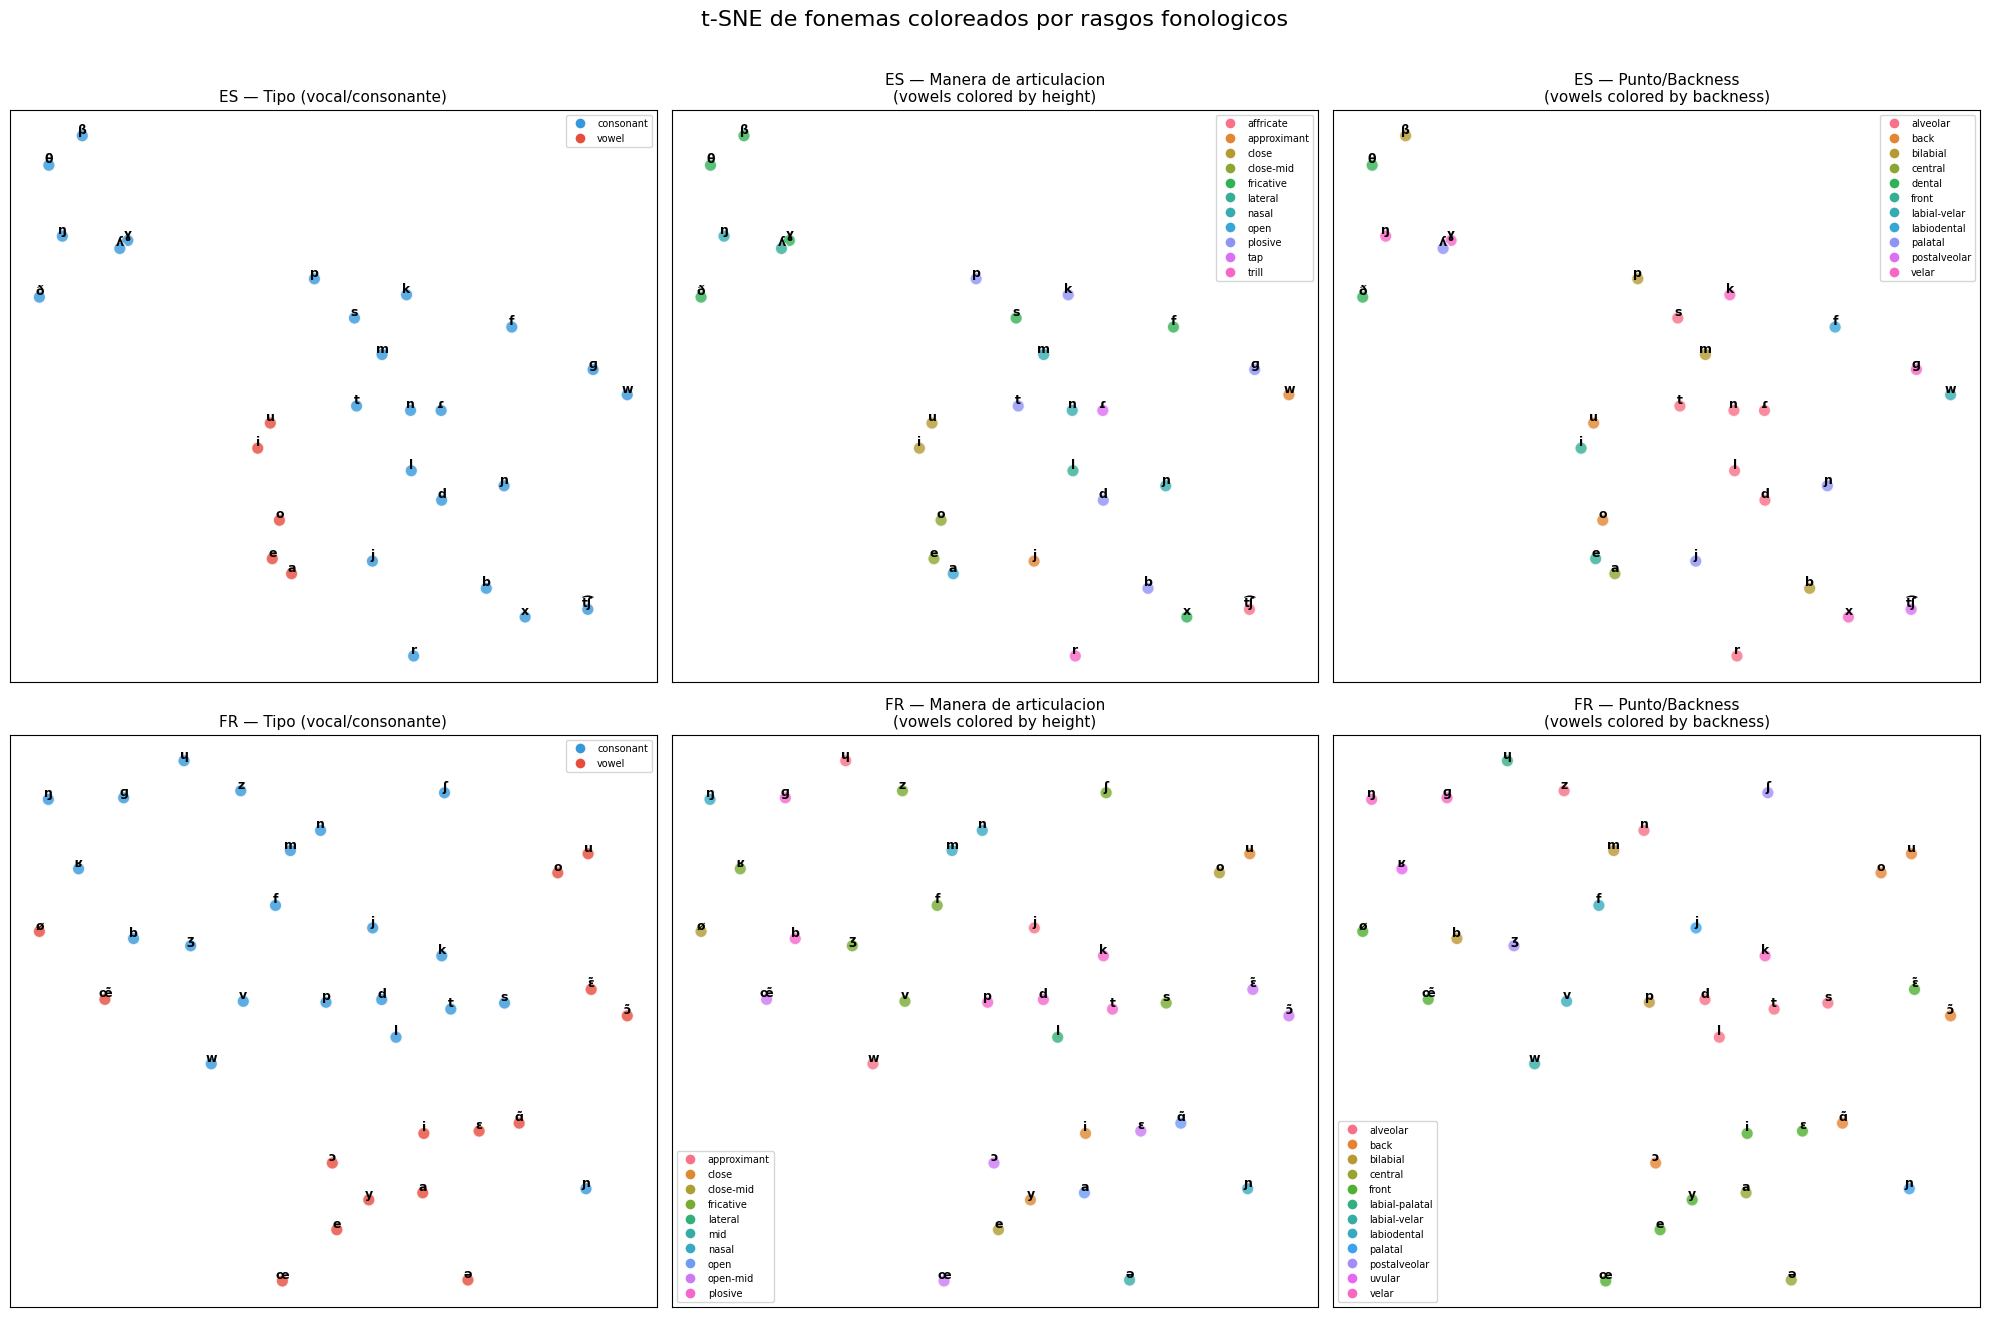

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

for row, lang in enumerate(["es", "fr"]):
    tokens, vectors = get_filtered_vectors(models["phoneme"][lang], lang)
    feats = get_phoneme_features(lang)
    
    tsne = TSNE(n_components=2, perplexity=min(8, len(tokens)-1),
                random_state=42, max_iter=2000)
    coords = tsne.fit_transform(vectors)
    
    # Color schemes for each feature
    color_maps = [
        ("type", "Tipo (vocal/consonante)", {"vowel": "#e74c3c", "consonant": "#3498db"}),
        ("manner" if lang == "fr" else "manner",
         "Manera de articulacion",
         None),  # auto color
        ("place" if feats.columns.isin(["place"]).any() else "backness",
         "Punto/Backness",
         None),
    ]
    
    for col, (feature, title, cmap) in enumerate(color_maps):
        ax = axes[row][col]
        
        # Get feature values for each token
        feat_vals = []
        for t in tokens:
            f = PHONEME_FEATURES.get(t, {})
            if feature == "manner" and f.get("type") == "vowel":
                feat_vals.append(f.get("height", "?"))
            elif feature == "place" and f.get("type") == "vowel":
                feat_vals.append(f.get("backness", "?"))
            else:
                feat_vals.append(f.get(feature, "?"))
        
        unique_vals = sorted(set(feat_vals))
        if cmap is None:
            palette = sns.color_palette("husl", len(unique_vals))
            cmap = {v: palette[i] for i, v in enumerate(unique_vals)}
        
        colors = [cmap.get(v, "gray") for v in feat_vals]
        
        ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=80, alpha=0.8, edgecolors="white")
        
        # Label each phoneme
        for i, t in enumerate(tokens):
            ax.annotate(t, (coords[i, 0], coords[i, 1]),
                       fontsize=9, ha="center", va="bottom", fontweight="bold")
        
        # Legend
        handles = [plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=cmap[v], markersize=8, label=v) for v in unique_vals]
        ax.legend(handles=handles, loc="best", fontsize=7)
        
        subtitle = f"{lang.upper()} — {title}"
        if feature == "manner":
            subtitle += "\n(vowels colored by height)"
        elif feature == "place":
            subtitle += "\n(vowels colored by backness)"
        ax.set_title(subtitle, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("t-SNE de fonemas coloreados por rasgos fonologicos", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("tsne_phonemes.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. K-means clustering vs rasgos fonologicos (purity y ARI)

Evaluamos cuantitativamente si los clusters de k-means recuperan categorias fonologicas. Probamos diferentes k y comparamos contra tipo, manera y punto de articulacion.

In [4]:
from collections import Counter

def cluster_purity(labels_true, labels_pred):
    """Fraction of items in each cluster that belong to the majority class."""
    contingency = {}
    for lt, lp in zip(labels_true, labels_pred):
        contingency.setdefault(lp, []).append(lt)
    total = len(labels_true)
    purity = sum(Counter(v).most_common(1)[0][1] for v in contingency.values()) / total
    return purity


def get_feature_labels(tokens, feature):
    """Get ground truth labels for a phonological feature."""
    labels = []
    for t in tokens:
        f = PHONEME_FEATURES.get(t, {})
        if feature == "type":
            labels.append(f.get("type", "?"))
        elif feature == "manner":
            if f.get("type") == "vowel":
                labels.append("vowel")  # group all vowels as one manner class
            else:
                labels.append(f.get("manner", "?"))
        elif feature == "voiced":
            if f.get("type") == "vowel":
                labels.append("voiced")  # all vowels are voiced
            else:
                labels.append("voiced" if f.get("voiced") else "voiceless")
        elif feature == "place":
            if f.get("type") == "vowel":
                labels.append(f.get("backness", "?"))
            else:
                labels.append(f.get("place", "?"))
    return labels


results = []
for lang in ("es", "fr"):
    tokens, vectors = get_filtered_vectors(models["phoneme"][lang], lang)
    
    for feature in ("type", "manner", "voiced", "place"):
        true_labels = get_feature_labels(tokens, feature)
        n_classes = len(set(true_labels))
        
        for k in range(2, min(12, len(tokens))):
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            pred = km.fit_predict(vectors)
            
            results.append({
                "Lang": lang.upper(),
                "Feature": feature,
                "n_classes": n_classes,
                "k": k,
                "Purity": cluster_purity(true_labels, pred),
                "ARI": adjusted_rand_score(true_labels, pred),
                "Homogeneity": homogeneity_score(true_labels, pred),
                "Silhouette": silhouette_score(vectors, pred) if k < len(tokens) else np.nan,
            })

cluster_df = pd.DataFrame(results)

# Show best k per feature (by ARI)
best = cluster_df.loc[cluster_df.groupby(["Lang", "Feature"])["ARI"].idxmax()]
best[["Lang", "Feature", "n_classes", "k", "Purity", "ARI", "Homogeneity", "Silhouette"]].round(3)

,Lang,Feature,n_classes,k,Purity,ARI,Homogeneity,Silhouette
19,ES,manner,9,11,0.655,0.224,0.597,0.091
39,ES,place,11,11,0.586,0.260,0.625,0.091
9,ES,type,2,11,0.966,0.132,0.797,0.091
24,ES,voiced,2,6,0.793,0.008,0.245,0.418
56,FR,manner,6,8,0.639,0.320,0.449,0.068
79,FR,place,12,11,0.583,0.202,0.578,0.041
46,FR,type,2,8,0.944,0.460,0.703,0.068
69,FR,voiced,2,11,0.889,0.045,0.539,0.041


## 3. ARI por feature a traves de k

Como evoluciona el Adjusted Rand Index al variar k, para cada rasgo fonologico.

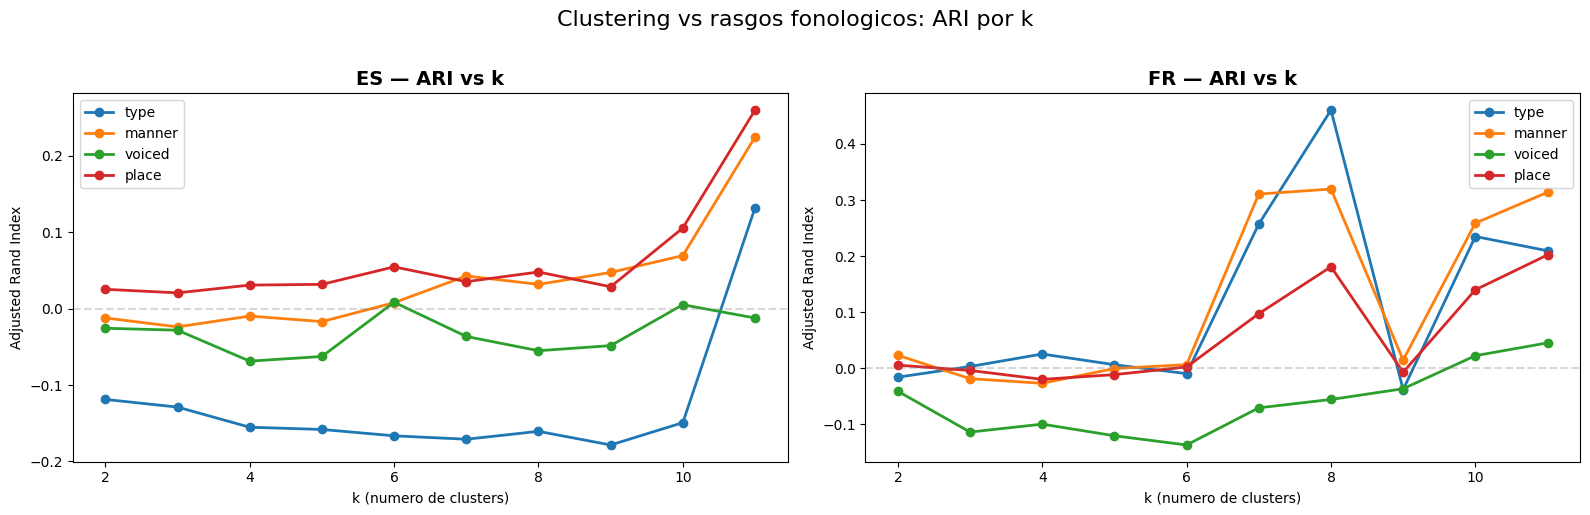

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, lang in enumerate(["ES", "FR"]):
    ax = axes[idx]
    subset = cluster_df[cluster_df["Lang"] == lang]
    for feature in ("type", "manner", "voiced", "place"):
        feat_data = subset[subset["Feature"] == feature]
        ax.plot(feat_data["k"], feat_data["ARI"], marker="o", label=feature, linewidth=2)
    
    ax.set_xlabel("k (numero de clusters)")
    ax.set_ylabel("Adjusted Rand Index")
    ax.set_title(f"{lang} — ARI vs k", fontsize=14, fontweight="bold")
    ax.legend()
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)

plt.suptitle("Clustering vs rasgos fonologicos: ARI por k", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("ari_by_k.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Probing lineal: clasificacion de rasgos fonologicos desde embeddings

Si un clasificador lineal simple (Logistic Regression) puede predecir un rasgo fonologico a partir del vector embedding, eso demuestra que el embedding codifica esa informacion de forma linealmente separable.

Usamos Leave-One-Out cross-validation dado el tamano pequeno de los datasets (29-36 fonemas).

In [6]:
from sklearn.dummy import DummyClassifier

probe_results = []

for lang in ("es", "fr"):
    tokens, vectors = get_filtered_vectors(models["phoneme"][lang], lang)
    
    for feature in ("type", "manner", "voiced", "place"):
        labels = get_feature_labels(tokens, feature)
        le = LabelEncoder()
        y = le.fit_transform(labels)
        
        n_classes = len(le.classes_)
        if n_classes < 2:
            continue
        
        loo = LeaveOneOut()
        
        # Logistic Regression probe
        clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
        scores = cross_val_score(clf, vectors, y, cv=loo, scoring="accuracy")
        
        # Majority baseline
        dummy = DummyClassifier(strategy="most_frequent")
        baseline = cross_val_score(dummy, vectors, y, cv=loo, scoring="accuracy")
        
        probe_results.append({
            "Lang": lang.upper(),
            "Feature": feature,
            "n_classes": n_classes,
            "LOO Accuracy": scores.mean(),
            "Baseline (majority)": baseline.mean(),
            "Lift over baseline": scores.mean() - baseline.mean(),
        })

probe_df = pd.DataFrame(probe_results)
probe_df.round(3)

,Lang,Feature,n_classes,LOO Accuracy,Baseline (majority),Lift over baseline
0,ES,type,2,0.828,0.828,0.000
1,ES,manner,9,0.414,0.241,0.172
2,ES,voiced,2,0.655,0.724,-0.069
3,ES,place,11,0.207,0.241,-0.034
4,FR,type,2,0.917,0.583,0.333
5,FR,manner,6,0.583,0.417,0.167
6,FR,voiced,2,0.833,0.833,0.000
7,FR,place,12,0.167,0.222,-0.056


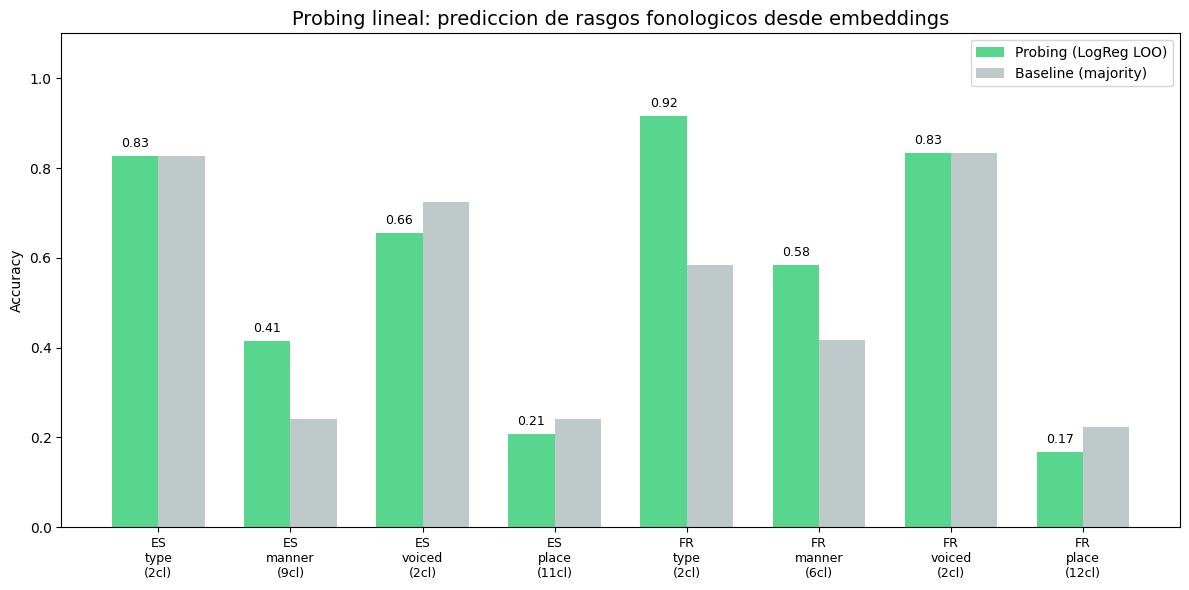

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(probe_df))
width = 0.35

bars1 = ax.bar(x - width/2, probe_df["LOO Accuracy"], width, label="Probing (LogReg LOO)", color="#2ecc71", alpha=0.8)
bars2 = ax.bar(x + width/2, probe_df["Baseline (majority)"], width, label="Baseline (majority)", color="#95a5a6", alpha=0.6)

ax.set_ylabel("Accuracy")
ax.set_title("Probing lineal: prediccion de rasgos fonologicos desde embeddings", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Lang']}\n{r['Feature']}\n({r['n_classes']}cl)" for _, r in probe_df.iterrows()],
                   fontsize=9)
ax.legend()
ax.set_ylim(0, 1.1)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("probing_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Clustering comparativo de silabas (fonestemas) FR vs ES

Clusterizamos las silabas en cada idioma y comparamos:
- Que tipo de silabas se agrupan juntas
- Si clusters analogos emergen en ambos idiomas
- Usamos las silabas compartidas como punto de referencia

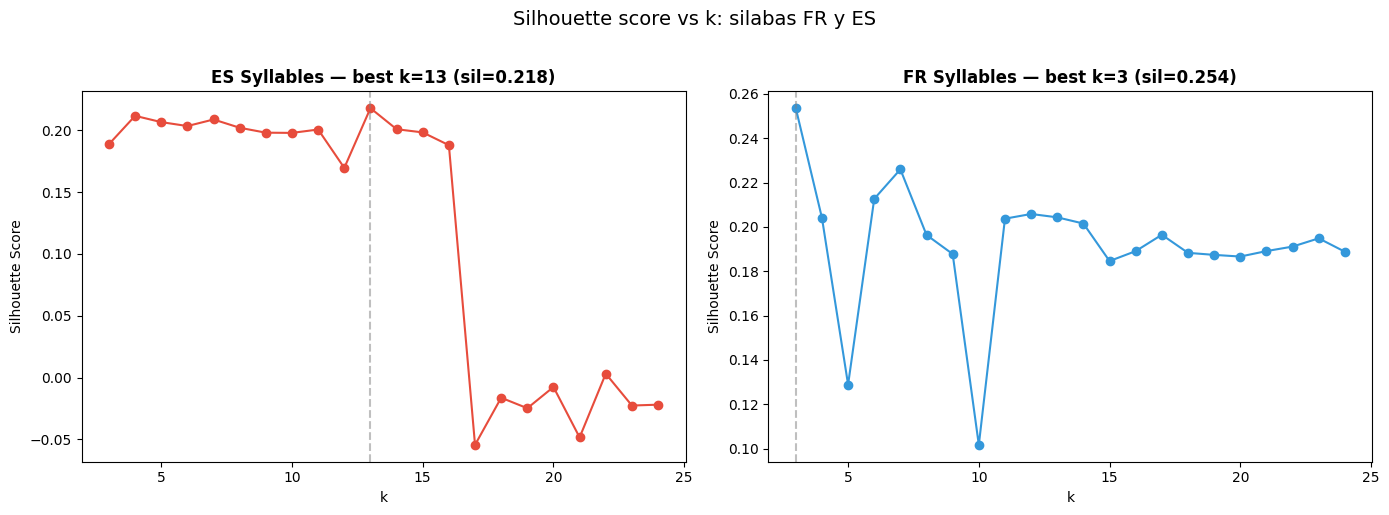

Best k: ES=13, FR=3


In [8]:
# Find optimal k via silhouette for syllables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_k = {}
for idx, lang in enumerate(["es", "fr"]):
    ax = axes[idx]
    model = models["syllable"][lang]
    vocab = sorted(get_vocab(model))
    vectors = np.array([model.wv[t] for t in vocab])
    
    # Sample for speed if needed
    if len(vocab) > 3000:
        rng = np.random.RandomState(42)
        sample_idx = rng.choice(len(vocab), 3000, replace=False)
        vectors_sample = vectors[sample_idx]
    else:
        vectors_sample = vectors
    
    k_range = range(3, 25)
    sil_scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        pred = km.fit_predict(vectors_sample)
        sil_scores.append(silhouette_score(vectors_sample, pred))
    
    ax.plot(list(k_range), sil_scores, marker="o", color="#e74c3c" if lang == "es" else "#3498db")
    best = list(k_range)[np.argmax(sil_scores)]
    best_k[lang] = best
    ax.axvline(x=best, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("k")
    ax.set_ylabel("Silhouette Score")
    ax.set_title(f"{lang.upper()} Syllables — best k={best} (sil={max(sil_scores):.3f})",
                fontsize=12, fontweight="bold")

plt.suptitle("Silhouette score vs k: silabas FR y ES", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("syllable_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best k: ES={best_k['es']}, FR={best_k['fr']}")

## 6. t-SNE de silabas compartidas coloreadas por cluster

Clusterizamos las silabas compartidas (1,497) en cada idioma por separado y visualizamos si los mismos fonestemas caen en clusters analogos.

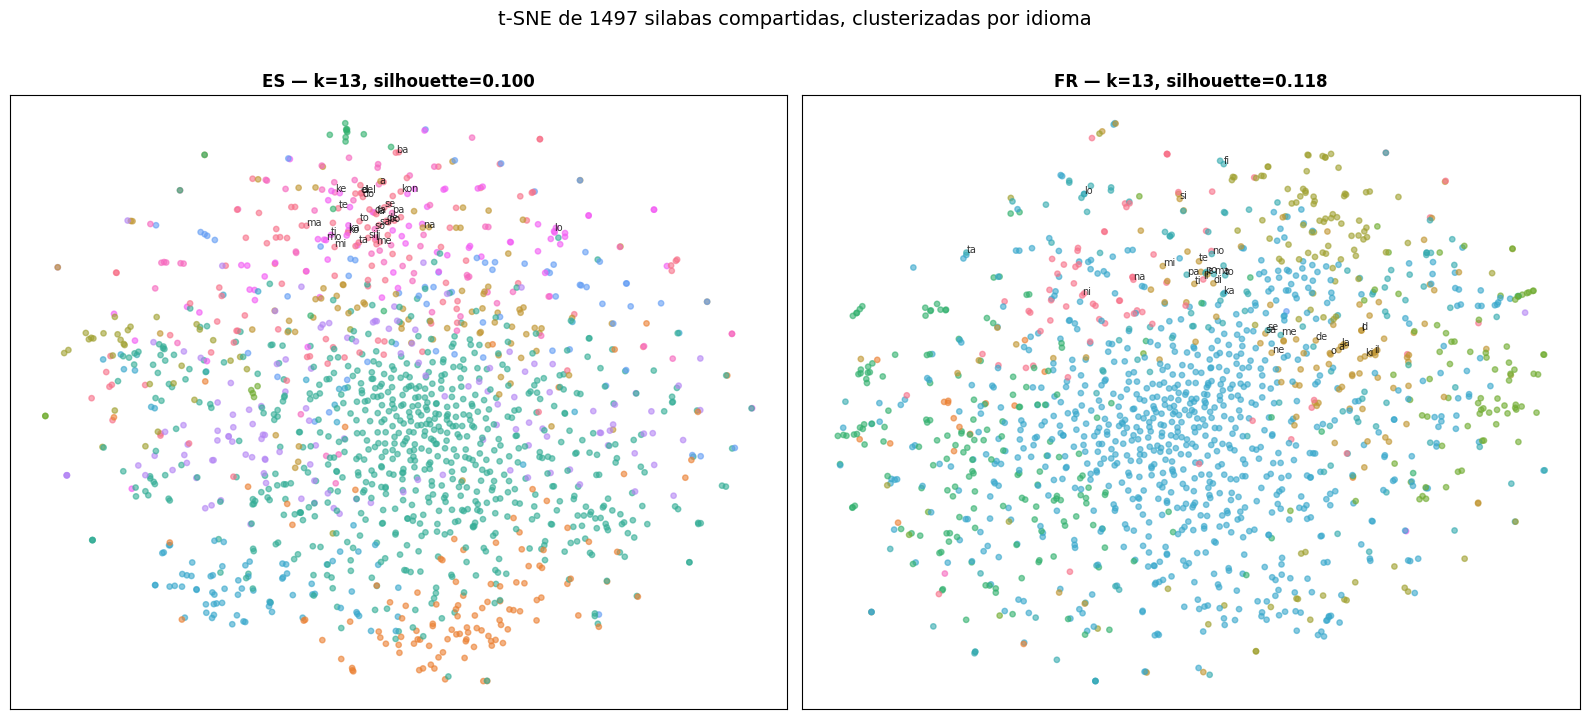

In [10]:
import json

# Load shared syllables
with open("shared_syllable_tokens.json", "r", encoding="utf-8") as f:
    shared_syllables = json.load(f)

# Use a common k (average of best_k or a reasonable fixed value)
k_shared = max(best_k["es"], best_k["fr"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cluster_assignments = {}

for idx, lang in enumerate(["es", "fr"]):
    ax = axes[idx]
    model = models["syllable"][lang]
    
    # Get vectors only for shared syllables
    vectors = np.array([model.wv[t] for t in shared_syllables])
    
    # Cluster
    km = KMeans(n_clusters=k_shared, random_state=42, n_init=10)
    labels = km.fit_predict(vectors)
    cluster_assignments[lang] = labels
    
    # t-SNE
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1500)
    coords = tsne.fit_transform(vectors)
    
    palette = sns.color_palette("husl", k_shared)
    colors = [palette[l] for l in labels]
    
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=15, alpha=0.6)
    
    # Label top-frequency syllables
    from loader import load_frequency
    freq_df = load_frequency("syllable", lang).set_index("token")["freq"]
    top_shared = sorted(shared_syllables, key=lambda t: freq_df.get(t, 0), reverse=True)[:30]
    
    for t in top_shared:
        i = shared_syllables.index(t)
        ax.annotate(t, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)
    
    sil = silhouette_score(vectors, labels)
    ax.set_title(f"{lang.upper()} — k={k_shared}, silhouette={sil:.3f}", fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"t-SNE de {len(shared_syllables)} silabas compartidas, clusterizadas por idioma", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("syllable_tsne_shared.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Concordancia de clusters entre idiomas

Para las silabas compartidas: si una silaba esta en el cluster X en ES, esta tambien en un cluster analogo en FR? Medimos con ARI entre las asignaciones ES y FR.

Cross-linguistic cluster concordance (shared syllables, k=13):
  Adjusted Rand Index:          0.1942
  Normalized Mutual Information: 0.1077

Permutation test (1000 permutations):
  Observed ARI: 0.1942
  Null ARI mean: 0.0002 (std=0.0115)
  p-value: 0.0000
  SIGNIFICANT (alpha=0.05)


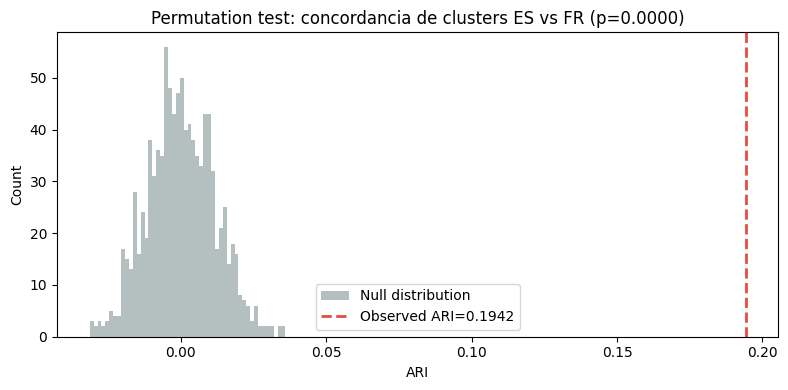

In [11]:
from sklearn.metrics import normalized_mutual_info_score

# Compare cluster assignments of shared syllables across languages
ari_cross = adjusted_rand_score(cluster_assignments["es"], cluster_assignments["fr"])
nmi_cross = normalized_mutual_info_score(cluster_assignments["es"], cluster_assignments["fr"])

print(f"Cross-linguistic cluster concordance (shared syllables, k={k_shared}):")
print(f"  Adjusted Rand Index:          {ari_cross:.4f}")
print(f"  Normalized Mutual Information: {nmi_cross:.4f}")
print()

# Permutation test: is this ARI significantly above chance?
n_perms = 1000
rng = np.random.RandomState(42)
ari_null = []
for _ in range(n_perms):
    perm = rng.permutation(cluster_assignments["fr"])
    ari_null.append(adjusted_rand_score(cluster_assignments["es"], perm))

ari_null = np.array(ari_null)
p_value = (ari_null >= ari_cross).mean()

print(f"Permutation test ({n_perms} permutations):")
print(f"  Observed ARI: {ari_cross:.4f}")
print(f"  Null ARI mean: {ari_null.mean():.4f} (std={ari_null.std():.4f})")
print(f"  p-value: {p_value:.4f}")
print(f"  {'SIGNIFICANT' if p_value < 0.05 else 'NOT significant'} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ari_null, bins=50, alpha=0.7, color="#95a5a6", label="Null distribution")
ax.axvline(x=ari_cross, color="#e74c3c", linewidth=2, linestyle="--", label=f"Observed ARI={ari_cross:.4f}")
ax.set_xlabel("ARI")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test: concordancia de clusters ES vs FR (p={p_value:.4f})", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("cluster_concordance_permtest.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Inspeccion cualitativa: que silabas se agrupan juntas?

Mostramos el contenido de los clusters mas grandes para ver si hay patrones fonestemicos reconocibles.

In [12]:
# Show cluster contents for shared syllables in both languages
for lang in ("es", "fr"):
    print(f"\n{'='*60}")
    print(f"  {lang.upper()} — Cluster contents (shared syllables, k={k_shared})")
    print(f"{'='*60}")
    
    labels = cluster_assignments[lang]
    freq_df = load_frequency("syllable", lang).set_index("token")["freq"]
    
    for c in range(k_shared):
        members = [shared_syllables[i] for i in range(len(shared_syllables)) if labels[i] == c]
        # Sort by frequency
        members_sorted = sorted(members, key=lambda t: freq_df.get(t, 0), reverse=True)
        print(f"\n  Cluster {c} ({len(members)} syllables):")
        print(f"    Top 15: {members_sorted[:15]}")


  ES — Cluster contents (shared syllables, k=13)

  Cluster 0 (122 syllables):
    Top 15: ['de', 'la', 'ta', 'te', 'se', 'el', 'do', 'to', 'i', 'ko', 'si', 'ma', 'da', 'kon', 'ba']

  Cluster 1 (116 syllables):
    Top 15: ['s', 'kk', 't', 'of', 'wi', 'ɡ', 'ss', 'wa', 'wn', 'ds', 'nei', 'ste', 'bum', 'sta', 'ɡt']

  Cluster 2 (86 syllables):
    Top 15: ['na', 'sia', 'ɡo', 'fwe', 'nal', 'pu', 'dja', 'io', 'ɲa', 'nis', 'ɲo', 'ksi', 'nja', 'bli', 'mun']

  Cluster 3 (32 syllables):
    Top 15: ['klo', 'ato', 'tei', 'fos', 'kleo', 'fla', 'bak', 'plas', 'mus', 'adn', 'ɡlu', 'ɡli', 'jo', 'lak', 'loi']

  Cluster 4 (6 syllables):
    Top 15: ['ɡlo', 'ii', 'ib', 'ksks', 'iks', 'ksb']

  Cluster 5 (15 syllables):
    Top 15: ['las', 'tes', 'das', 'tas', 'kas', 'nas', 'sas', 'bas', 'ɲas', 'ɡwas', 'bjas', 'pjas', 'ljas', 'njas', 'mjas']

  Cluster 6 (698 syllables):
    Top 15: ['n', 'f', 'l', 'we', 'swi', 'bon', 'klis', 'bid', 'sei', 'ɡle', 'ei', 'tein', 'et', 'ski', 'dt']

  Cluster 7 (1 syl